<font color="FF3B3B"><h1 align="left">Sistema multimodal para la detección e identificación de especies de hongos mediante visión por computador y modelos de lenguaje</h1></font>
<font color="#6E6E6E"><h2 align="left">Entrenamiento del modelo complejo</h2></font>

#### David Alejandro Pedroza De Jesús

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import os
import tensorflow as tf
from google.colab import drive
from tensorflow.keras import layers, models
import shutil
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import plot_model
from tensorflow.keras import activations
from google.colab import drive

In [2]:
drive.mount('/content/drive/')
shutil.copy("/content/drive/MyDrive/kaggle.zip","/content/")
!unzip kaggle.zip
#shutil.copy("/content/drive/MyDrive/InfoEspecies.csv","/content/")

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39104medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39105medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39106medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39107medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39108medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39109medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39110medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39111medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39112medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39113medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39114medium.jpg  
  inflating: kaggle/working/merged_dataset/

# Carga de los datos

In [3]:
rutas_val = pd.read_csv("kaggle/working/val.csv")
rutas_train = pd.read_csv("kaggle/working/train.csv")
rutas_test = pd.read_csv("kaggle/working/test.csv")
info_especies = pd.read_csv("InfoEspecies.csv")
info_especies = info_especies.drop(info_especies.columns[0], axis= "columns")

train = pd.merge(info_especies, rutas_train, on='label', how='inner')
test = pd.merge(info_especies, rutas_test, on='label', how='inner')
val = pd.merge(info_especies, rutas_val, on='label', how='inner')

In [4]:

def ArreglarLasRutas(df):
    rutas_nuevas = []
    for path in df.image_path:
        path = path.lstrip("/")
        rutas_nuevas.append(path)
    df.image_path = rutas_nuevas

def Modificar_direc(df_rutas, subset):
    os.makedirs(f"Data/{subset}", exist_ok=True)

    ArreglarLasRutas(df_rutas)

    for path, label in zip(df_rutas.image_path, df_rutas.label):
        destino = f"Data/{subset}/{label}/"
        os.makedirs(destino, exist_ok=True)
        print(f"Copiando {path} --> {destino}")
        shutil.copy(path, destino)
        print(f"Terminado {label}")

In [5]:
Modificar_direc(train, "train")
Modificar_direc(test, "test")
Modificar_direc(val, "valid")

Se han truncado las últimas 5000 líneas del flujo de salida.
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23452medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/22011medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/20680medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/21100medium.jpg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19837medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23382medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19047medium.jpeg --> Data/val

In [6]:
train_dir = "Data/train"
test_dir = "Data/test"
val_dir = "Data/valid"


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(64, 64),
    batch_size=128,
    label_mode='int'
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(64, 64),
    batch_size=128,
    label_mode='int'
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(64, 64),
    batch_size=128,
    label_mode='int'
)

normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
valid_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 30068 files belonging to 54 classes.
Found 6442 files belonging to 54 classes.
Found 6443 files belonging to 54 classes.


# Creamos el modelo

In [7]:
num_classes = 54


model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3)),
    layers.BatchNormalization(),
    layers.Activation(activations.relu),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Activation(activations.relu),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, epochs=60, validation_data=valid_ds)

test_loss, test_acc = model.evaluate(test_ds)
print(f"Precisión en test: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 107s 417ms/step - accuracy: 0.2732 - loss: 3.0133 - val_accuracy: 0.1780 - val_loss: 3.8598
Epoch 2/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 89s 379ms/step - accuracy: 0.3934 - loss: 2.3494 - val_accuracy: 0.3037 - val_loss: 3.0281
Epoch 3/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 77s 328ms/step - accuracy: 0.4505 - loss: 2.0551 - val_accuracy: 0.3916 - val_loss: 2.3183
Epoch 4/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 75s 299ms/step - accuracy: 0.4869 - loss: 1.8695 - val_accuracy: 0.4372 - val_loss: 2.0896
Epoch 5/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 299ms/step - accuracy: 0.5263 - loss: 1.7076 - val_accuracy: 0.3980 - val_loss: 2.2955
Epoch 6/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - accuracy: 0.5533 - loss: 1.5799 - val_accuracy: 0.4316 - val_loss: 2.2764
Epoch 7/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 299ms/step - accuracy: 0.5765 - loss: 1.4713 - val_accuracy: 0.4458 - val_loss: 2.2036
Epoch 8/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 61s 259ms/step - accuracy: 0.6147 - loss: 

# Arquitectura del modelo

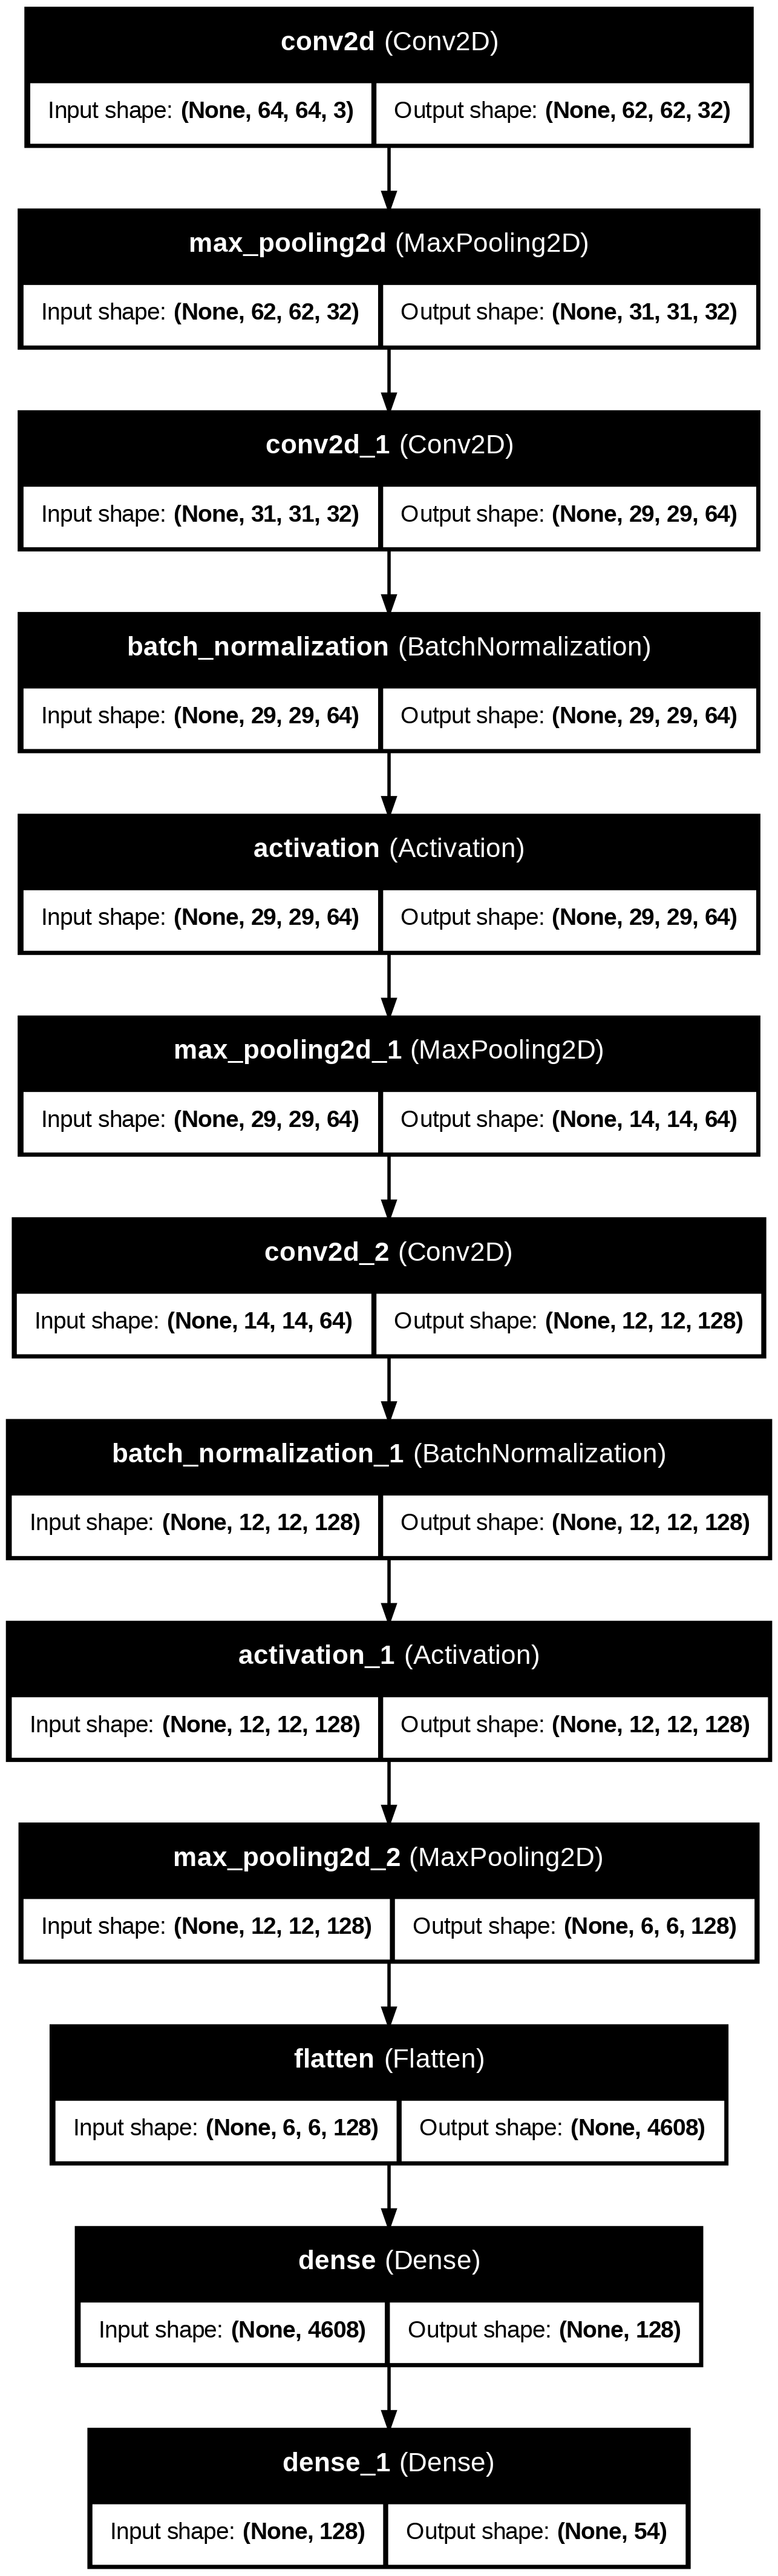

In [8]:
plot_model(model, to_file='modelo.png', show_shapes=True, show_layer_names=True)

# graficos error

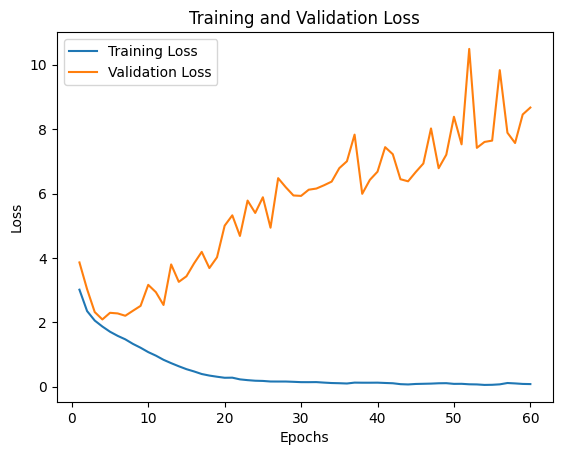

In [9]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(list(range(1,61)),train_loss, label='Training Loss')
plt.plot(list(range(1,61)),val_loss,label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

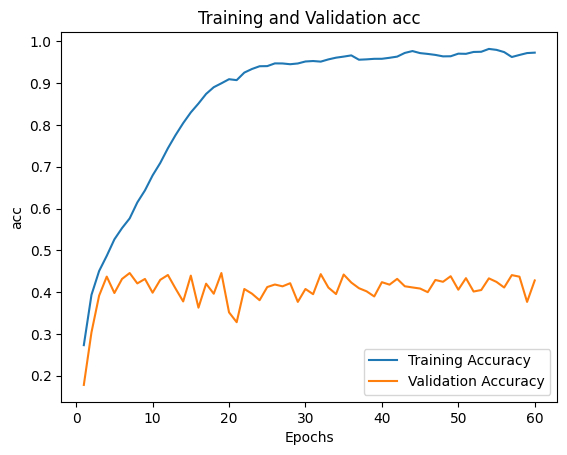

In [10]:
val_acc = history.history['val_accuracy']
train_acc = history.history['accuracy']
plt.plot(list(range(1,61)),train_acc, label='Training Accuracy')
plt.plot(list(range(1,61)),val_acc,label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation acc')
plt.xlabel('Epochs')
plt.ylabel('acc')
plt.show()

# matriz de confusión

In [11]:
# Inicializar listas
y_true = []
y_pred = []

# Iterar sobre el dataset de prueba
for images, labels in test_ds:
    y_true.extend(labels.numpy())                        # Labels reales
    preds = model.predict(images)                        # Predicciones del modelo
    y_pred.extend(np.argmax(preds, axis=1))              # Clase con mayor probabilidad

# Convertir a arrays de numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━

In [12]:
cm = confusion_matrix(y_true,y_pred ,normalize= "true")

In [21]:
from tensorflow.keras.applications.resnet import preprocess_input

IMG_SIZE = (64, 64)
BATCH_SIZE = 64

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "Data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)
class_names = test_dataset.class_names

test_dataset  = test_dataset.map(lambda x, y: (normalization_layer(x), y))


Found 6442 files belonging to 54 classes.


In [22]:
# Inicializar listas
y_true = []
y_pred = []

# Iterar sobre el dataset de prueba
for images, labels in test_ds:
    y_true.extend(labels.numpy())                        # Labels reales
    preds = model.predict(images)                        # Predicciones del modelo
    y_pred.extend(np.argmax(preds, axis=1))              # Clase con mayor probabilidad

# Convertir a arrays de numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━

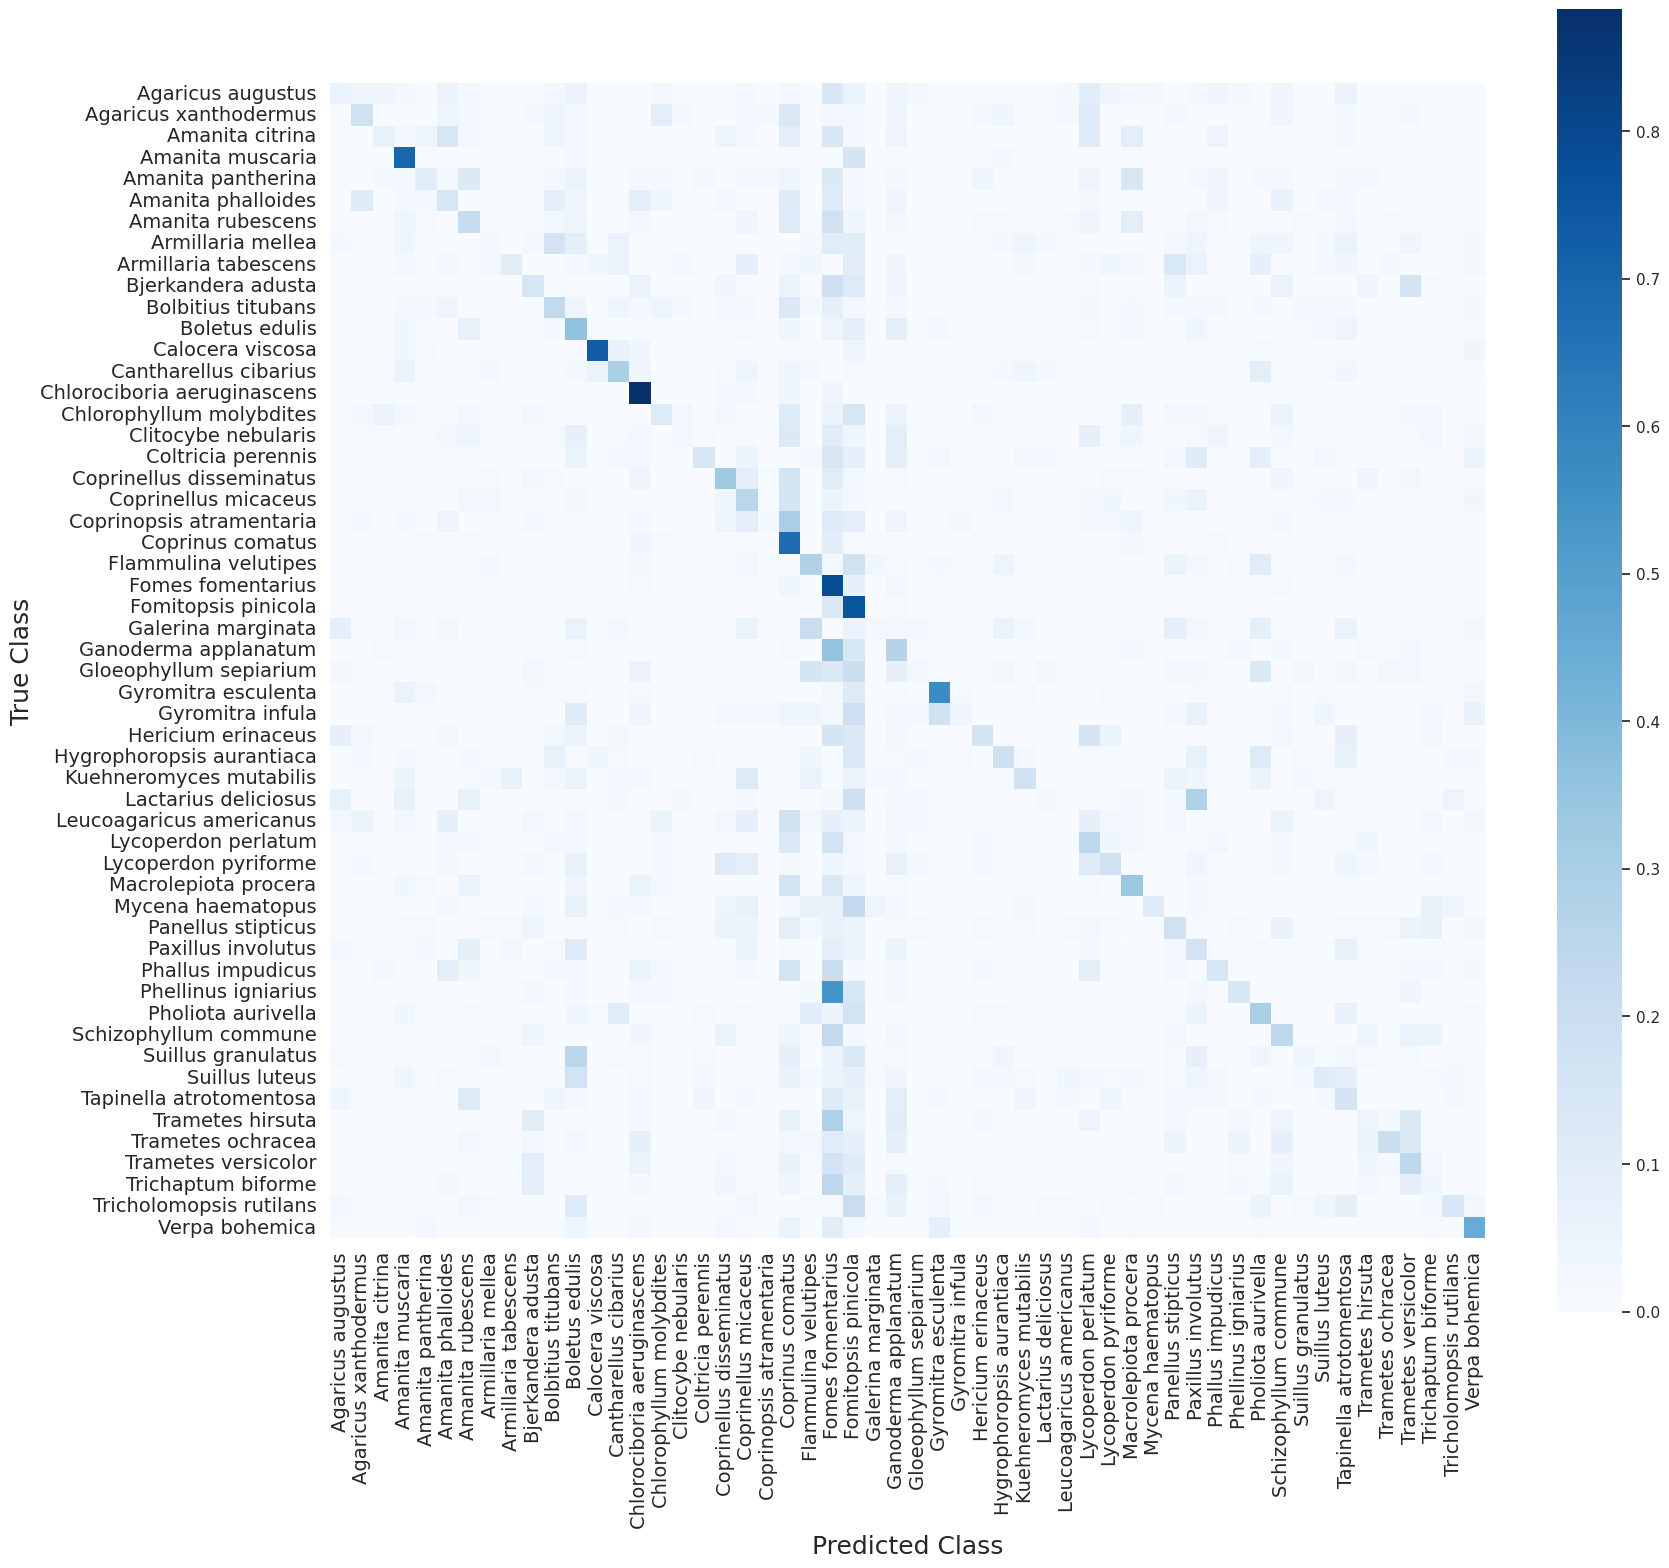

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista con los nombres de las clases
# class_names = ["Clase 1", "Clase 2", ..., "Clase N"]

plt.figure(figsize=(18, 16))

sns.set_theme(style="white")  # estilo uniforme (tema claro)

ax = sns.heatmap(
    cm,
    cmap="Blues",
    annot=False,          # elimina los valores numéricos
    cbar=True,
    square=True,
    xticklabels=class_names,
    yticklabels=class_names
)


# Etiquetas tipo YOLO
ax.set_xlabel("Predicted Class", fontsize=18)
ax.set_ylabel("True Class", fontsize=18)

# Tamaño de las etiquetas de los ejes
ax.tick_params(axis='x', labelsize=14, rotation=90)
ax.tick_params(axis='y', labelsize=14, rotation=0)

# Ajuste para evitar que se corten las etiquetas
plt.tight_layout()

plt.show()

In [24]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.11      0.06      0.08        51
           1       0.26      0.17      0.21        46
           2       0.18      0.07      0.10        44
           3       0.86      0.70      0.77       687
           4       0.13      0.10      0.11        51
           5       0.12      0.15      0.13        48
           6       0.16      0.22      0.18        79
           7       0.05      0.02      0.03        49
           8       0.22      0.09      0.13        53
           9       0.14      0.14      0.14        70
          10       0.16      0.23      0.19        48
          11       0.33      0.36      0.34       220
          12       0.70      0.73      0.71        63
          13       0.49      0.29      0.37       126
          14       0.29      0.88      0.43        51
          15       0.12      0.11      0.12        35
          16       0.20      0.03      0.05        68
          17       0.29    

In [25]:
model.save('modelo_Complejo.keras')